# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [3]:
# При необходимости скачайте данные в каталог data/
!mkdir -p data
!wget https://storage.yandexcloud.net/mle-data/ym/tracks.parquet -P data
!wget https://storage.yandexcloud.net/mle-data/ym/catalog_names.parquet -P data
!wget https://storage.yandexcloud.net/mle-data/ym/interactions.parquet -P data

tracks = pd.read_parquet("data/tracks.parquet")
catalog_names = pd.read_parquet("data/catalog_names.parquet")
interactions = pd.read_parquet("data/interactions.parquet")

--2026-04-04 00:48:47--  https://storage.yandexcloud.net/mle-data/ym/tracks.parquet
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18938128 (18M) [application/x-www-form-urlencoded]
Saving to: ‘data/tracks.parquet.1’

tracks.parquet.1    100%[===================>]  18.06M  50.2MB/s    in 0.4s    

2026-04-04 00:48:48 (50.2 MB/s) - ‘data/tracks.parquet.1’ saved [18938128/18938128]

--2026-04-04 00:48:48--  https://storage.yandexcloud.net/mle-data/ym/catalog_names.parquet
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 36146495 (34M) [application/x-www-form-urlencoded]
Saving to: ‘data/catalog_names.parquet.1’

catalog_name

In [4]:
tracks.info()
display(tracks.head(5))
catalog_names.info()
display(catalog_names.head(5))
interactions.info()
display(interactions.head(5))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack


<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


# Обзор данных

tracks.parquet - данные о треках:  
 - track_id — идентификатор музыкального трека;  
 - albums —  список идентификаторов альбомов, содержащих трек;  
 - artists — список идентификаторов исполнителей трека;  
 - genres — список идентификаторов жанров, к которым принадлежит трек.

In [5]:
tracks.head()

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


In [6]:
is_unique = tracks['track_id'].nunique()
total_count = len(tracks)
is_unique, total_count

(1000000, 1000000)

Проверим есть ли данные с пустыми альбомами, артистами и жанрами.

In [7]:
tracks[tracks["albums"].str.len() == 0]

,track_id,albums,artists,genres
310821,20200372,[],[],[]
310826,20200380,[],[],[]
312469,20305116,[],[],[]
312474,20305121,[],[],[]
320353,20756854,[],[],[]
326588,21196099,[],[],[]
326592,21196103,[],[],[]
326594,21196105,[],[],[]
326596,21196107,[],[],[]
326598,21196109,[],[],[]


In [8]:
tracks[tracks["artists"].str.len() == 0]

,track_id,albums,artists,genres
146031,3599314,[389925],[],"[68, 86]"
146163,3599591,[389944],[],"[68, 86]"
177544,4790215,[533785],[],"[68, 86]"
218922,10063296,[1083742],[],"[11, 20]"
231455,12122918,[1315834],[],[68]
...,...,...,...,...
999868,101201589,[12649219],[],"[62, 77]"
999876,101219571,[9444321],[],"[62, 83, 77]"
999901,101243616,[11700332],[],"[62, 93]"
999920,101292599,[9331881],[],"[62, 90, 77, 84]"


In [9]:
tracks[tracks['genres'].str.len() == 0]

,track_id,albums,artists,genres
490,2520,"[249, 163801, 163802, 324616, 17542430, 189498...",[2259],[]
3069,16776,"[1479, 5319, 6093, 8467, 10641, 90867, 163801,...",[978],[]
3077,16801,"[1479, 163801, 9287549, 9377183, 9424994, 1201...",[10520],[]
4192,23752,"[2001, 3722, 4973, 6104, 6558, 23866, 37052, 7...",[13373],[]
6645,38012,"[3147, 60099, 530836, 1115289, 2490724, 818446...",[16758],[]
...,...,...,...,...
997667,99412992,[20764551],[10029101],[]
999192,100497082,[21098340],[15936615],[]
999703,100923319,[21233460],[5271861],[]
999704,100923322,[21233460],[5271861],[]


В данных по трекам в каждом столбце кроме `track_id` есть пропуски (пустые списки). Удалим их.

In [10]:
tracks = tracks[tracks['artists'].map(len) > 0]

In [11]:
tracks.shape

(984631, 4)

In [12]:
tracks = tracks[tracks['genres'].map(len) > 0]
tracks = tracks[tracks['albums'].map(len) > 0]
tracks.shape

(980977, 4)

In [13]:
tracks['track_id'] = tracks['track_id'].astype('int32')

In [14]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 980977 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   track_id  980977 non-null  int32 
 1   albums    980977 non-null  object
 2   artists   980977 non-null  object
 3   genres    980977 non-null  object
dtypes: int32(1), object(3)
memory usage: 33.7+ MB


In [15]:
tracks.head()

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


catalog_names.parquet - имена артистов, названия альбомов, треков и жанров:  
 - id — идентификатор одной из каталожных единиц (трека, альбома, исполнителя, жанра);  
 - type — тип идентификатора;  
 - name — имя (название) каталожной единицы.

In [16]:
catalog_names.head()

,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack


In [17]:
catalog_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


Рассмотрим какое количество типов находится в `catalog_name`.

In [18]:
catalog_names["type"].value_counts()

type
track     1000000
album      658724
artist     153581
genre         166
Name: count, dtype: int64

Проверим есть ли дубликаты по `id`. 

In [19]:
catalog_names[catalog_names['id'].duplicated()]

,id,type,name
658728,12,artist,Phil Everly
658735,34,artist,Miles Davis
658736,36,artist,Baker
658741,87,artist,Michael Schenker
658744,93,artist,Femi Kuti
...,...,...,...
1141043,21314698,track,No Good For You
1141108,21320653,track,Oh!
1141114,21321251,track,Lady in Red
1141142,21327491,track,Waiting Here


In [20]:
catalog_names[catalog_names["id"] == 12]

,id,type,name
1,12,album,Wild Young Hearts
658728,12,artist,Phil Everly
812317,12,genre,shanson


`id` для разных типов могут повторяться.

Теперь расмотрим есть ли дубликаты по `name`.

In [21]:
names_duplicate = catalog_names[catalog_names['name'].duplicated()]
names_duplicate

,id,type,name
10,43,album,Blues Six Pack
11,45,album,Blues Six Pack
13,49,album,Graffiti Soul
28,94,album,Jazz Six Pack
29,95,album,Blues Six Pack
...,...,...,...
1812466,101478482,track,На лицо
1812467,101490148,track,Без капли мысли
1812468,101493057,track,SKITTLES
1812469,101495927,track,Москва


867353 строки с дубликатом по имени. Возьмем `Blues Six Pack`  и посмотрим сколько дублей с ним.

In [22]:
catalog_names[catalog_names["name"] == "Blues Six Pack"]

,id,type,name
4,26,album,Blues Six Pack
10,43,album,Blues Six Pack
11,45,album,Blues Six Pack
29,95,album,Blues Six Pack
34519,91414,album,Blues Six Pack


5 дублей только для одного `Blues Six Pack`. Удалим дубликаты и оставим только первое вхождение в названии.

In [23]:
catalog_names = catalog_names.drop_duplicates(subset=["type","name"], keep="first")

In [24]:
catalog_names.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1122702 entries, 0 to 1812468
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   id      1122702 non-null  int64 
 1   type    1122702 non-null  object
 2   name    1122702 non-null  object
dtypes: int64(1), object(2)
memory usage: 34.3+ MB


Отсортируем столбец `name` для нахождения не валидных названий.

In [25]:
catalog_names.sort_values(by="name")

,id,type,name
795021,8865715,artist,\tDrake
786980,7709071,artist,!
131744,2081150,album,!
925200,1710520,track,!
43510,169465,album,! (Знак оклику)
...,...,...,...
1641925,65866709,track,🧘‍♂️ Morning routine (S03E03) + Transcript
1632665,64726613,track,🧬 Science (Season 2 Finale 🏁) + Transcript
1708710,74597869,track,🧭 Traveling (S05E01) + Transcript
1624044,63880930,track,🧸 Toys (S02E08) + Transcript


In [26]:
import re
import pandas as pd

def clean_text(text):
    if pd.isna(text):
        return text
    
    text = re.sub(r'[^\w\sа-яА-Яa-zA-Z0-9]', ' ', str(text))
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()


In [27]:
catalog_names['name'] = catalog_names['name'].apply(clean_text)

In [28]:
catalog_names.sort_values(by="name")

,id,type,name
224321,3409614,album,
511437,11568156,album,
973698,4191614,track,
1588729,59892881,track,
974355,4209950,track,
...,...,...,...
1670720,69607892,track,휴일 Lazy
494820,10922873,album,희망의 목소리 Voice Of Hope
1500453,50451058,track,힘내 DON T GIVE UP
1714041,75454138,track,０


Удалим названия в которых меньше двух символов. Почему сразу где символов меньше двух, в данных есть очень короткие имена которые не несут в себе никакой разумной информации.

In [29]:
catalog_names = catalog_names[catalog_names['name'].str.len().gt(2)]

In [30]:
catalog_names.sort_values(by="name")

,id,type,name
1055513,14631870,track,0 0
440939,8940691,album,0 0
1577365,58719563,track,0 0
954489,2845446,track,0 0 Where Evil Dwells
390203,7151984,album,0 00
...,...,...,...
513895,11671681,album,훗 Hoot The 3rd Mini Album
1670720,69607892,track,휴일 Lazy
494820,10922873,album,희망의 목소리 Voice Of Hope
1500453,50451058,track,힘내 DON T GIVE UP


Выявилась еще одна проблема - числа в названиях.

In [31]:
mask = ~catalog_names['name'].astype(str).str.contains(r'^\s*\d+(?:\s+\d+)*\s*$', na=False, regex=True)

catalog_names = catalog_names[mask].reset_index(drop=True)

catalog_names.sort_values(by="name")

,id,type,name
686473,2845446,track,0 0 Where Evil Dwells
230418,5174962,album,0 1 1 I PROMISE YOU
1000261,58287313,track,0 3 темноты
969381,51282126,track,0 Angel
341417,11009478,album,0 Choir
...,...,...,...
351040,11671681,album,훗 Hoot The 3rd Mini Album
1047890,69607892,track,휴일 Lazy
339472,10922873,album,희망의 목소리 Voice Of Hope
965122,50451058,track,힘내 DON T GIVE UP


Числа в названиях остались, но теперь там есть и полноценное название, а не просто числа. Так что оставим так.

interactions.parquet - данные о том, какие пользователи прослушали тот или иной трек:  
- user_id — идентификатор пользователя,  
- track_id — идентификатор музыкального трека,  
- track_seq — номер места трека в истории пользователя,  
- started_at — дата начала прослушивания трека.

In [32]:
interactions.head()

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


In [33]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


Оставим в `interactions` только те треки которые есть в `tracks`.

In [34]:
interactions = interactions[interactions['track_id'].isin(tracks['track_id'])].reset_index(drop=True)

In [35]:
missing_tracks = set(interactions['track_id']) - set(tracks['track_id'])
print(f"Отсутствующих track_id в tracks: {len(missing_tracks)}")

Отсутствующих track_id в tracks: 0


In [36]:
interactions["track_id"].nunique()

980977

In [37]:
len(interactions)

222184449

In [38]:
interactions["track_seq"].describe()

count    2.221844e+08
mean     4.620044e+02
std      8.248128e+02
min      1.000000e+00
25%      5.600000e+01
50%      1.810000e+02
75%      5.050000e+02
max      1.663700e+04
Name: track_seq, dtype: float64

Максимальный номер места в истории пользователя превышает 16 тыс., а 75% значений укладываются в 505. Логично предположить что нам не нужно знать о треках места которых не входят в 900 или 1000. Поэтому оставим только взаимодействия с номерами места трека в истории пользователя <= 1000.

In [39]:
interactions_clean = interactions[interactions["track_seq"] <= 1000].reset_index(drop=True)
interactions_clean.head()

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


In [40]:
print(f"Процент оставшихся взаимодействий: {len(interactions_clean)*100/len(interactions):.2f}%")

Процент оставшихся взаимодействий: 87.98%


# Выводы

*Какие проблемы есть в данных?*
- Пустые значение в названиях(именах) авторов, альбомов, жанров.
- Дубликаты по имени и типу.
- Некорректные названия треков. Напимер: 0 0.

*Решения проблем*
- Очистка данных от пустых значений.
- Удаление дубликатов (оставили только первое вхождение).
- Очистка данных от неккоректных названий.

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

In [41]:
interactions_clean["started_at_month"] = pd.to_datetime(interactions_clean["started_at"]).dt.month.astype('int8')

interactions_clean.head()

,user_id,track_id,track_seq,started_at,started_at_month
0,0,99262,1,2022-07-17,7
1,0,589498,2,2022-07-19,7
2,0,590262,3,2022-07-21,7
3,0,590303,4,2022-07-22,7
4,0,590692,5,2022-07-22,7


count    1.372767e+06
mean     1.618515e+02
std      3.507933e+02
min      1.000000e+00
50%      5.500000e+01
90%      3.880000e+02
95%      6.490000e+02
99%      1.574000e+03
max      1.663000e+04
dtype: float64

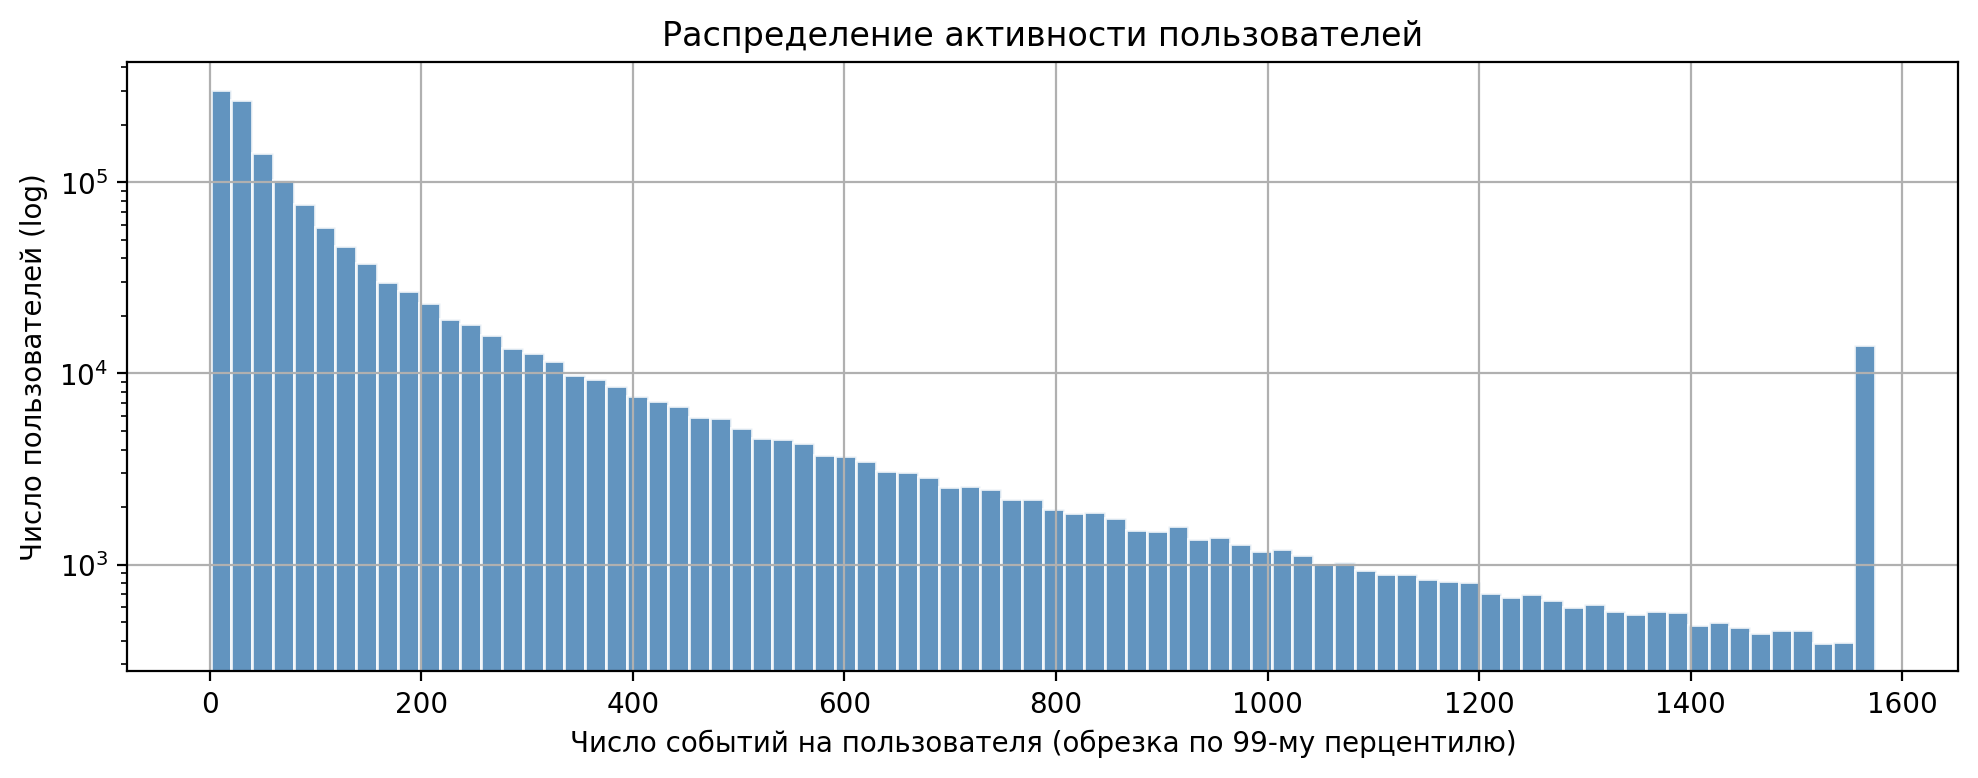

Медиана событий на пользователя: 55
Пользователей с одним событием: 964


In [42]:
user_event_counts = interactions.groupby("user_id").size()
display(user_event_counts.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

fig, ax = plt.subplots(figsize=(10, 4))
upper = user_event_counts.quantile(0.99)
user_event_counts.clip(upper=upper).hist(bins=80, ax=ax, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_yscale("log")
ax.set_xlabel("Число событий на пользователя (обрезка по 99-му перцентилю)")
ax.set_ylabel("Число пользователей (log)")
ax.set_title("Распределение активности пользователей")
plt.tight_layout()
plt.show()

print(f"Медиана событий на пользователя: {user_event_counts.median():.0f}")
print(f"Пользователей с одним событием: {(user_event_counts == 1).sum():,}")


Наиболее популярные треки

,track_id,listens,unique_users,genres,artists
0,53404,111062,111062,"[13, 14, 102]",[9262]
1,33311009,106921,106921,"[14, 102]",[675068]
2,178529,101924,101924,"[41, 47]",[36800]
3,35505245,99490,99490,"[3, 75]","[4611844, 588511]"
4,65851540,86670,86670,"[11, 20]",[1554548]
5,24692821,86246,86246,[70],[1194096]
6,32947997,85886,85886,[11],[381067]
7,51241318,85244,85244,[74],"[1802873, 3135644, 9012818]"
8,795836,85042,85042,"[11, 14, 102]",[680]
9,45499814,84748,84748,"[11, 20]",[5007577]


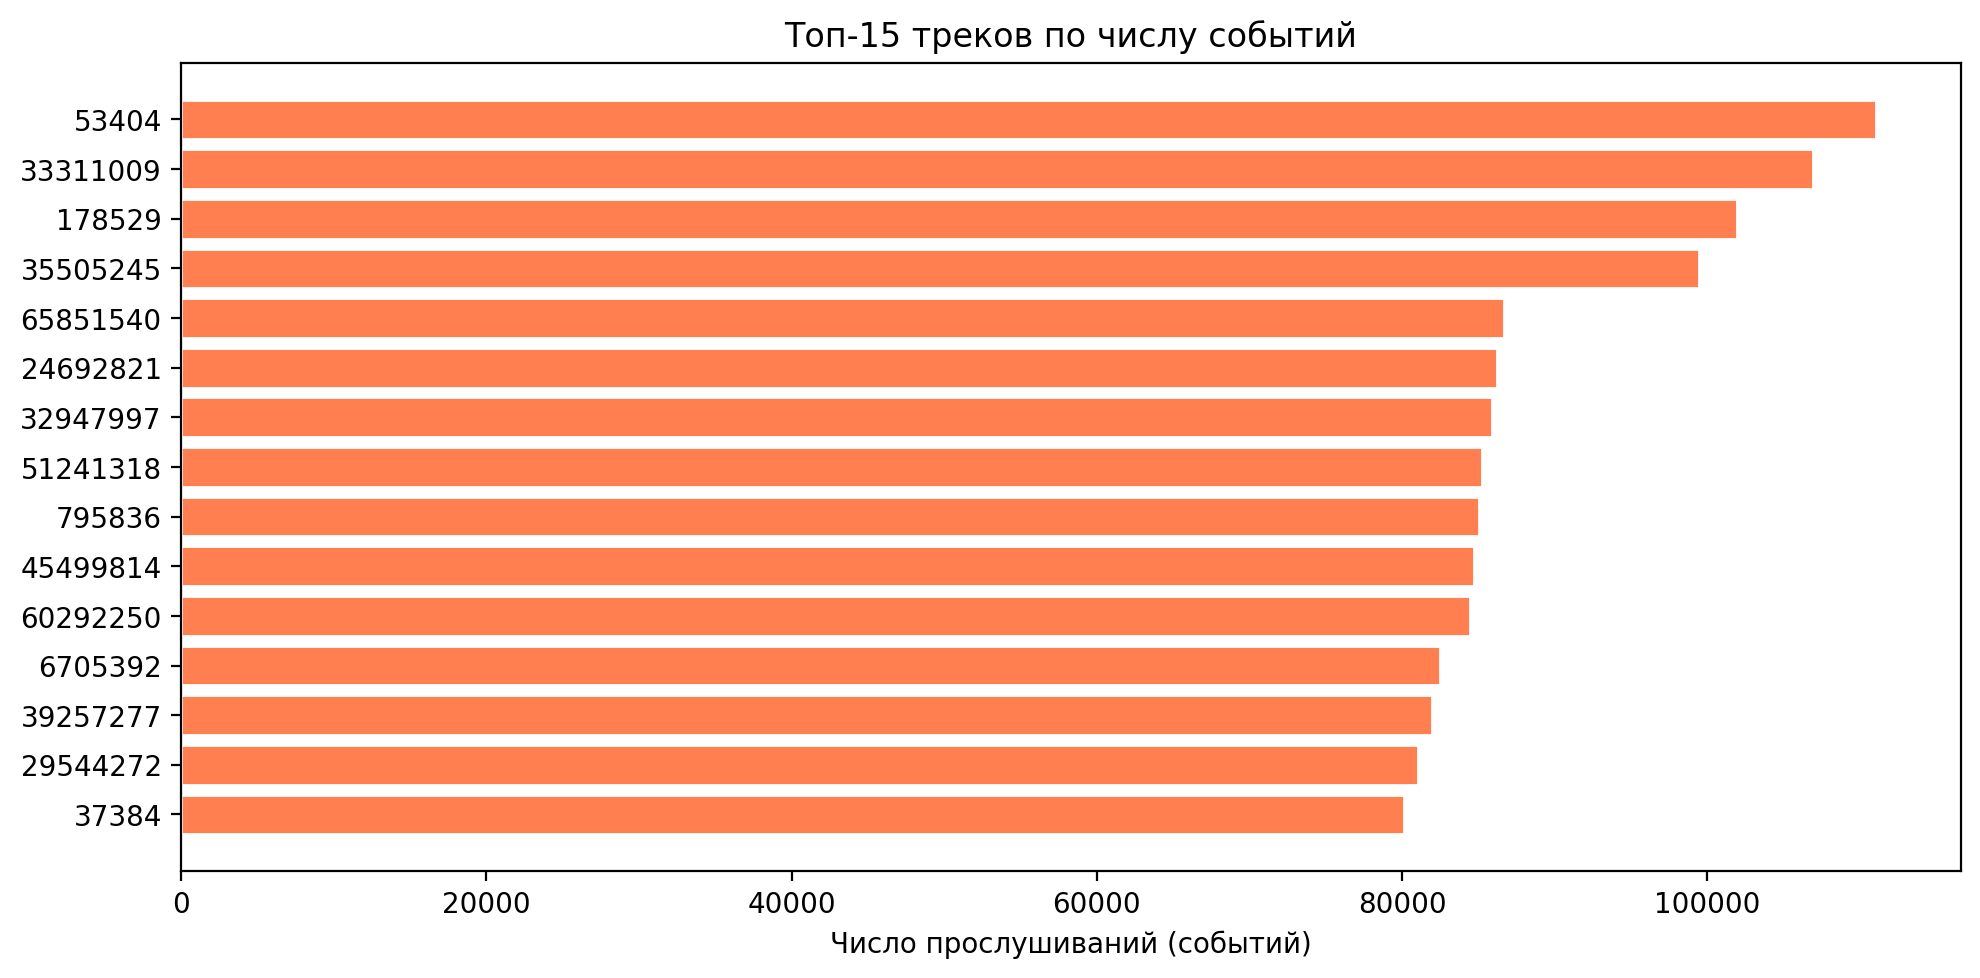

In [43]:
track_popularity = (
    interactions.groupby("track_id")
    .agg(listens=("user_id", "count"), unique_users=("user_id", "nunique"))
    .sort_values("listens", ascending=False)
    .reset_index()
)
track_popularity = track_popularity.merge(
    tracks[["track_id", "genres", "artists"]],
    on="track_id",
    how="left",
)
display(track_popularity.head(20))

top_n = 15
fig, ax = plt.subplots(figsize=(10, 5))
sub = track_popularity.head(top_n).iloc[::-1].copy()
sub["label"] = sub["track_id"].fillna("?").astype(str).str.slice(0, 45)
ax.barh(sub["label"], sub["listens"], color="coral", edgecolor="white")
ax.set_xlabel("Число прослушиваний (событий)")
ax.set_title(f"Топ-{top_n} треков по числу событий")
plt.tight_layout()
plt.show()


Наиболее популярные жанры

genres
11     55578305
75     37799821
102    31091989
20     26626234
3      25303695
68     20120694
16     16291557
2      13166147
14     12772620
47     12437375
44     12194657
13     10111562
70      9993665
325     6896593
25      5910628
19      4960458
6       4068264
21      3969678
50      3768826
74      3287311
Name: listens, dtype: int64

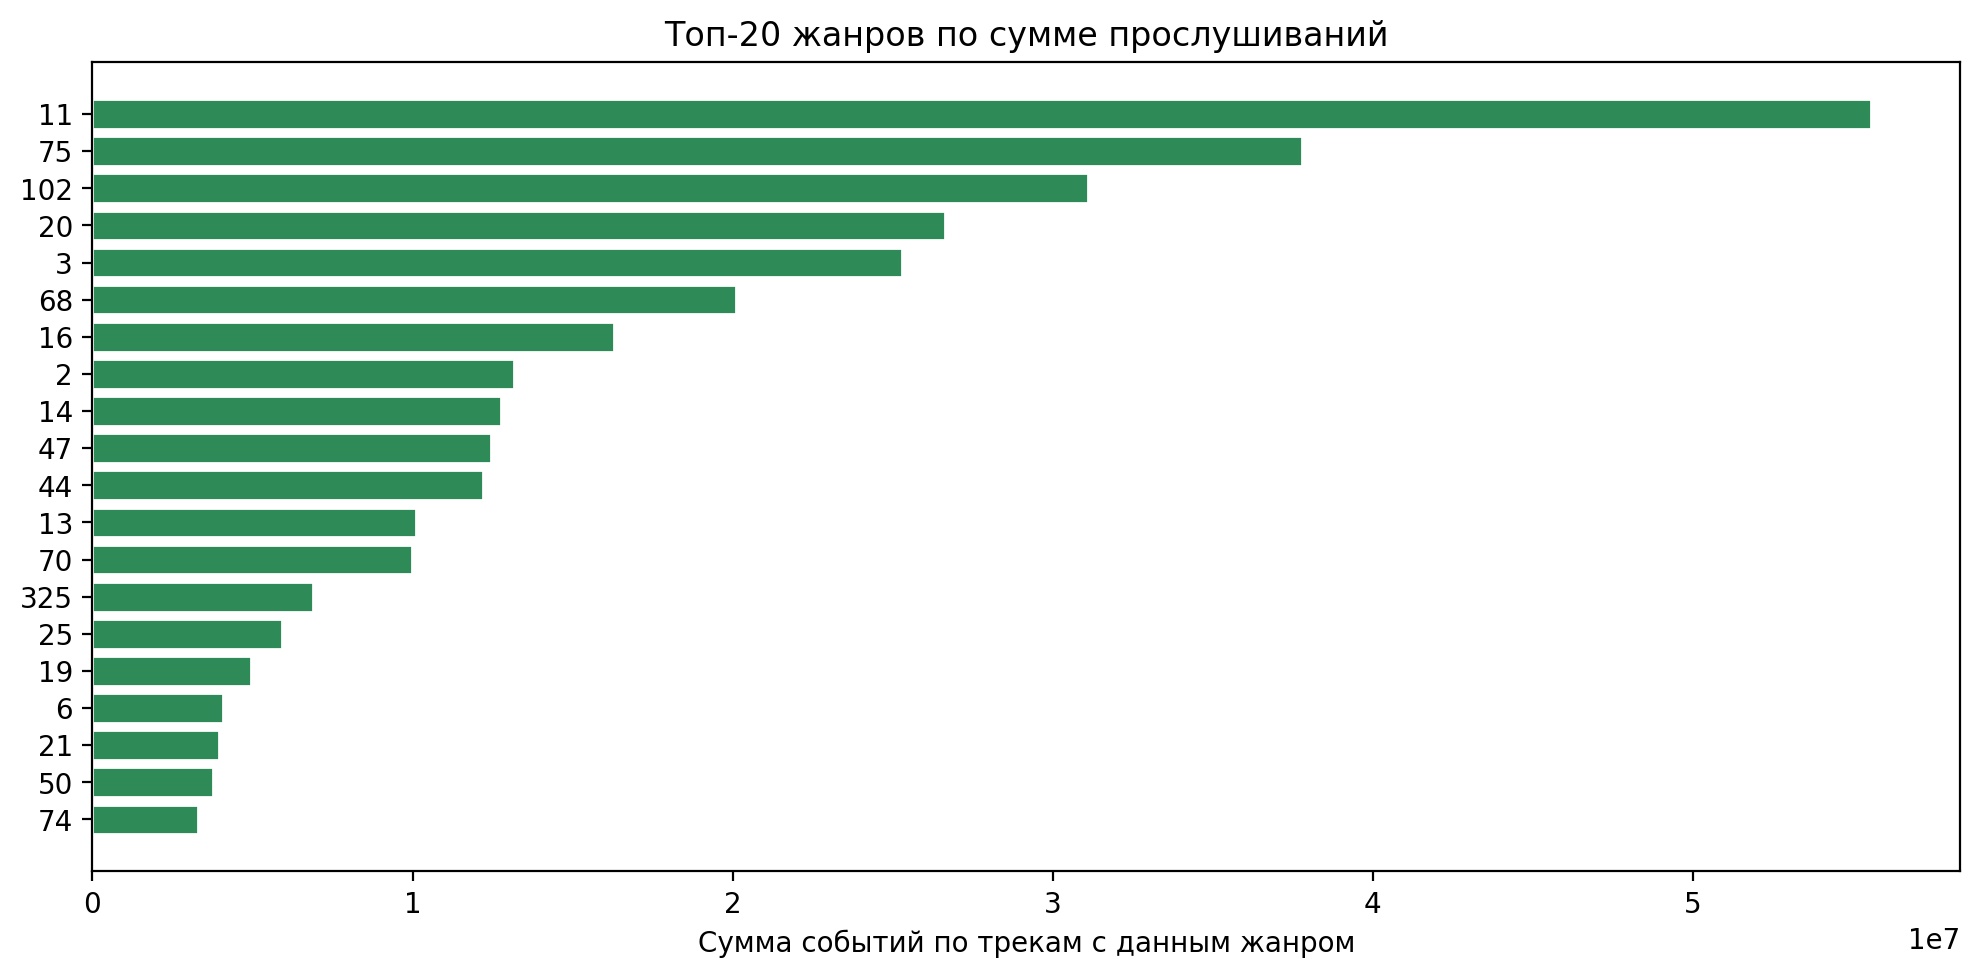

In [44]:
listens_per_track = interactions.groupby("track_id").size().rename("listens")
genre_rows = tracks[["track_id", "genres"]].explode("genres").dropna(subset=["genres"])
genre_rows = genre_rows.merge(listens_per_track, on="track_id", how="left").fillna({"listens": 0})
genre_totals = genre_rows.groupby("genres")["listens"].sum().sort_values(ascending=False)
display(genre_totals.head(20))

fig, ax = plt.subplots(figsize=(10, 5))
g = genre_totals.head(20).iloc[::-1]
ax.barh(g.index.astype(str), g.values, color="seagreen", edgecolor="white")
ax.set_xlabel("Сумма событий по трекам с данным жанром")
ax.set_title("Топ-20 жанров по сумме прослушиваний")
plt.tight_layout()
plt.show()


Треки, которые никто не прослушал

In [45]:
heard_track_ids = set(interactions["track_id"].unique())
catalog_track_ids = set(tracks["track_id"].unique())
unlistened_ids = catalog_track_ids - heard_track_ids

print(f"Треков без прослушиваний: {len(unlistened_ids):,}")

Треков без прослушиваний: 0


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

Разделим данные в `tracks` на отдельные строки. Это нужно для того чтобы очистить данные. Например от дубликатов номеров альбомов, таких как `3` и `2490753`.

In [46]:
tracks = tracks.explode("albums").explode("artists").explode("genres").reset_index(drop=True)
tracks

,track_id,albums,artists,genres
0,26,3,16,11
1,26,3,16,21
2,26,2490753,16,11
3,26,2490753,16,21
4,38,3,16,11
...,...,...,...,...
6686875,101493057,21403883,11865715,75
6686876,101495927,21404975,4462686,3
6686877,101495927,21404975,4462686,75
6686878,101521819,21414638,5056591,3


In [47]:
tracks = tracks.rename(columns={"albums":"album_id", "artists":"artist_id", "genres":"genre_id"})

In [48]:
tracks["track_name"] = tracks.merge(catalog_names[catalog_names["type"]=="track"],left_on="track_id",right_on="id",how="left")["name"]
tracks["album_name"] = tracks.merge(catalog_names[catalog_names["type"]=="album"],left_on="album_id",right_on="id",how="left")["name"]
tracks["artist_name"] = tracks.merge(catalog_names[catalog_names["type"]=="artist"],left_on="artist_id",right_on="id",how="left")["name"]
tracks["genre_name"] = tracks.merge(catalog_names[catalog_names["type"]=="genre"],left_on="genre_id",right_on="id",how="left")["name"]
tracks

,track_id,album_id,artist_id,genre_id,track_name,album_name,artist_name,genre_name
0,26,3,16,11,Complimentary Me,Taller Children,Elizabeth the Catapult,pop
1,26,3,16,21,Complimentary Me,Taller Children,Elizabeth the Catapult,folk
2,26,2490753,16,11,Complimentary Me,NaN,Elizabeth the Catapult,pop
3,26,2490753,16,21,Complimentary Me,NaN,Elizabeth the Catapult,folk
4,38,3,16,11,Momma s Boy,Taller Children,Elizabeth the Catapult,pop
...,...,...,...,...,...,...,...,...
6686875,101493057,21403883,11865715,75,SKITTLES,SKITTLES,WhyBaby,rap
6686876,101495927,21404975,4462686,3,NaN,NaN,NaN,rusrap
6686877,101495927,21404975,4462686,75,NaN,NaN,NaN,rap
6686878,101521819,21414638,5056591,3,NaN,NaN,Джарахов,rusrap


Появились пропуски в `album_name`, поскольку были удалены дубликаты названий. Удалим те поля, где есть хотя бы один пропуск. 

In [49]:
tracks = tracks.dropna().reset_index(drop=True)

Агрегируем данные обратно.

In [50]:
tracks = tracks.groupby("track_id").agg({'album_id':lambda x: list(set(list(x))),
                               'artist_id':lambda x: list(set(list(x))),
                               'genre_id':lambda x: list(set(list(x))),
                               'track_name':lambda x: list(set(list(x))),
                               'album_name':lambda x: list(set(list(x))),
                               'artist_name':lambda x: list(set(list(x))),
                               'genre_name':lambda x: list(set(list(x)))}).reset_index()
tracks

,track_id,album_id,artist_id,genre_id,track_name,album_name,artist_name,genre_name
0,26,[3],[16],"[11, 21]",[Complimentary Me],[Taller Children],[Elizabeth the Catapult],"[folk, pop]"
1,38,[3],[16],"[11, 21]",[Momma s Boy],[Taller Children],[Elizabeth the Catapult],"[folk, pop]"
2,135,[12],[84],[11],[Atticus],[Wild Young Hearts],[Noisettes],[pop]
3,136,[12],[84],[11],[24 Hours],[Wild Young Hearts],[Noisettes],[pop]
4,138,"[213505, 322, 12, 17294156, 72275]",[84],[11],[Don t Upset The Rhythm Go Baby Go],"[Don t Upset The Rhythm, 2000s Indie Nostalgia...",[Noisettes],[pop]
...,...,...,...,...,...,...,...,...
443818,101389552,[21374143],"[9171426, 9171427, 16066317, 16066318, 7194299]","[75, 44]",[ВОВА ВЕРНУЛСЯ],[NO OFFENCE],"[LEOYASHIN, Ugarel, GBAN, SAUCE SAYS, 163ONMYN...","[rap, foreignrap]"
443819,101389554,[21374143],[7194299],"[75, 44]",[АУТО],[NO OFFENCE],[163ONMYNECK],"[rap, foreignrap]"
443820,101392428,[21375241],[675102],"[75, 3]",[ДСВ 2022],[ДСВ 2022],[Типси Тип],"[rap, rusrap]"
443821,101490148,[21403052],[9078726],"[11, 20]",[Без капли мысли],[Без капли мысли],[Даня Милохин],"[ruspop, pop]"


Еще раз проверим треки которые есть в взаимодействии.

In [51]:
existing_tracks_list = tracks["track_id"].drop_duplicates().to_list()
interactions = interactions_clean[interactions_clean["track_id"].isin(existing_tracks_list)].reset_index(drop=True)
interactions

,user_id,track_id,track_seq,started_at,started_at_month
0,0,99262,1,2022-07-17,7
1,0,589498,2,2022-07-19,7
2,0,590262,3,2022-07-21,7
3,0,590303,4,2022-07-22,7
4,0,590692,5,2022-07-22,7
...,...,...,...,...,...
76889490,1374582,93571683,281,2022-12-29,12
76889491,1374582,94848971,283,2022-12-29,12
76889492,1374582,94960284,284,2022-12-29,12
76889493,1374582,97220301,289,2022-12-29,12


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `rec_sys/data/` и локально `data/prepared`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [52]:
items = tracks.copy()
events = interactions.copy()

In [53]:
!mkdir -p data/prepared
!mkdir -p data/recommendations

In [54]:
items.to_parquet("data/prepared/items.parquet")
events.to_parquet("data/prepared/events.parquet")

In [55]:
import boto3
from dotenv import load_dotenv
import os
import io
load_dotenv('.env')

AWS_ACCESS_KEY_ID = os.environ.get('AWS_ACCESS_KEY_ID')
AWS_SECRET_ACCESS_KEY = os.environ.get('AWS_SECRET_ACCESS_KEY')
S3_SERVICE_NAME = 's3'
S3_ENDPOINT_URL = os.environ.get('S3_ENDPOINT_URL')
BUCKET_NAME = os.environ.get('S3_BUCKET_NAME')

session = boto3.session.Session()

s3 = session.client(
        service_name=S3_SERVICE_NAME,
        endpoint_url=S3_ENDPOINT_URL,
        aws_access_key_id=AWS_ACCESS_KEY_ID,
        aws_secret_access_key=AWS_SECRET_ACCESS_KEY
    )

s3.upload_file('data/prepared/items.parquet', BUCKET_NAME, 'recsys/items.parquet')
s3.upload_file('data/prepared/events.parquet', BUCKET_NAME, 'recsys/events.parquet')

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

Для очистки памяти следует перезапустить kernel. Все импорты и файлы items.parquet и events.parquet будут загружены заново ниже.parquet

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [56]:
items = pd.read_parquet("data/prepared/items.parquet")
events = pd.read_parquet("data/prepared/events.parquet")

In [57]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76889495 entries, 0 to 76889494
Data columns (total 5 columns):
 #   Column            Dtype         
---  ------            -----         
 0   user_id           int32         
 1   track_id          int32         
 2   track_seq         int16         
 3   started_at        datetime64[ns]
 4   started_at_month  int8          
dtypes: datetime64[ns](1), int16(1), int32(2), int8(1)
memory usage: 1.4 GB


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [58]:
train_test_global_time_split_date = pd.to_datetime("2022-12-16")

train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date

events_train = events[train_test_global_time_split_idx].reset_index(drop=True)
events_test  = events[~train_test_global_time_split_idx].reset_index(drop=True)

In [59]:
events_train.to_parquet("data/prepared/events_train.parquet")
events_test.to_parquet("data/prepared/events_test.parquet")

In [60]:
display(events_train.shape, events_test.shape)

(72569756, 5)

(4319739, 5)

In [61]:
# количество пользователей в train и test
users_train = events_train["user_id"].drop_duplicates()
users_test = events_test['user_id'].drop_duplicates()
# количество пользователей, которые есть и в train, и в test
common_users = np.intersect1d(users_train.unique(), users_test.unique())

print(len(users_train), len(users_test), len(common_users)) 

1333368 597951 564421


In [62]:
same_user_id = np.intersect1d(events_train["user_id"].unique(), events_test["user_id"].unique())
cold_users = events_test.query('user_id not in @same_user_id')['user_id'].unique()
print(len(cold_users))

33530


# Топ популярных

In [63]:
from sklearn.preprocessing import MinMaxScaler

Рассчитаем рекомендации как топ популярных.

In [64]:
events_train = pd.read_parquet("data/prepared/events_train.parquet")
events_test = pd.read_parquet("data/prepared/events_test.parquet")

In [65]:
events_train.head()

,user_id,track_id,track_seq,started_at,started_at_month
0,0,99262,1,2022-07-17,7
1,0,589498,2,2022-07-19,7
2,0,590262,3,2022-07-21,7
3,0,590303,4,2022-07-22,7
4,0,590692,5,2022-07-22,7


In [66]:
item_popularity = events_train.groupby("track_id").agg(users=("user_id", "count"), track_seq_median=("track_seq", "median")).reset_index()
item_popularity

,track_id,users,track_seq_median
0,26,5,1.0
1,38,8,1.0
2,135,16,1.0
3,136,7,1.0
4,138,17,1.0
...,...,...,...
442605,101389552,5,284.0
442606,101389554,5,163.0
442607,101392428,2,387.0
442608,101490148,26,153.0


In [67]:
item_popularity["popularity"] = (item_popularity["users"]/item_popularity["users"].unique().sum())
item_popularity

,track_id,users,track_seq_median,popularity
0,26,5,1.0,1.467619e-07
1,38,8,1.0,2.348191e-07
2,135,16,1.0,4.696382e-07
3,136,7,1.0,2.054667e-07
4,138,17,1.0,4.989906e-07
...,...,...,...,...
442605,101389552,5,284.0,1.467619e-07
442606,101389554,5,163.0,1.467619e-07
442607,101392428,2,387.0,5.870478e-08
442608,101490148,26,153.0,7.631621e-07


In [68]:
item_popularity['popularity'].describe()

count    4.426100e+05
mean     4.812579e-06
std      3.298328e-05
min      2.935239e-08
25%      1.761143e-07
50%      3.815811e-07
75%      1.320858e-06
max      2.398648e-03
Name: popularity, dtype: float64

In [69]:
scaler = MinMaxScaler()
item_popularity[["users_norm", "popularity_norm"]] = scaler.fit_transform(
    item_popularity[["users", "popularity"]]
)

In [70]:
item_popularity["popularity_score"] = (
    item_popularity["users_norm"] * item_popularity["popularity_norm"]
)

In [71]:
item_popularity = item_popularity.sort_values(["popularity_score"], ascending=[False])

In [72]:
item_popularity.head(100)

,track_id,users,track_seq_median,popularity,users_norm,popularity_norm,popularity_score
200736,24692821,81719,69.0,0.002399,1.000000,1.000000,1.000000
5689,37384,79512,7.0,0.002334,0.972992,0.972992,0.946714
243355,32947997,77256,69.0,0.002268,0.945385,0.945385,0.893753
156380,17079396,71870,65.0,0.002110,0.879476,0.879476,0.773478
317711,47627256,67785,115.0,0.001990,0.829487,0.829487,0.688048
...,...,...,...,...,...,...,...
5774,38318,31908,7.0,0.000937,0.390453,0.390453,0.152453
3078,18855,31788,6.0,0.000933,0.388984,0.388984,0.151309
72251,1695521,31483,60.0,0.000924,0.385252,0.385252,0.148419
359814,60725745,31480,93.0,0.000924,0.385215,0.385215,0.148391


In [73]:
top_k_pop_items = item_popularity.head(100)

In [74]:
items.head()

,track_id,album_id,artist_id,genre_id,track_name,album_name,artist_name,genre_name
0,26,[3],[16],"[11, 21]",[Complimentary Me],[Taller Children],[Elizabeth the Catapult],"[folk, pop]"
1,38,[3],[16],"[11, 21]",[Momma s Boy],[Taller Children],[Elizabeth the Catapult],"[folk, pop]"
2,135,[12],[84],[11],[Atticus],[Wild Young Hearts],[Noisettes],[pop]
3,136,[12],[84],[11],[24 Hours],[Wild Young Hearts],[Noisettes],[pop]
4,138,"[213505, 322, 12, 17294156, 72275]",[84],[11],[Don t Upset The Rhythm Go Baby Go],"[Don t Upset The Rhythm, 2000s Indie Nostalgia...",[Noisettes],[pop]


In [75]:
top_k_pop_items = top_k_pop_items.merge(items[["track_id",'track_name','album_name','artist_name','genre_name']], on="track_id")
top_k_pop_items[["track_id", "users", "popularity", "popularity_score", 'track_name','album_name','artist_name','genre_name']].head(25)

,track_id,users,popularity,popularity_score,track_name,album_name,artist_name,genre_name
0,24692821,81719,0.002399,1.000000,[Way Down We Go],"[Hits Stars Winter 2018, DFM Dance 8, A B, Sum...",[KALEO],[indie]
1,37384,79512,0.002334,0.946714,[Zombie],"[MNM Sing Your Song Back To The 90s Edition, C...",[The Cranberries],"[rock, allrock]"
2,32947997,77256,0.002268,0.893753,[Shape of You],[Shape of You],[Ed Sheeran],[pop]
3,17079396,71870,0.002110,0.773478,[Take Me To Church],"[Indonesia Trending Hits, Sync and Sing, Lugna...",[Hozier],[indie]
4,47627256,67785,0.001990,0.688048,[Cradles],[Cradles],[Sub Urban],[electronics]
5,148345,65604,0.001926,0.644484,[Californication],"[Californication, The Studio Album Collection ...",[Red Hot Chili Peppers],"[rock, allrock]"
6,51516485,64328,0.001888,0.619657,[bad guy],"[שירים לבידוד נעים, Festival FOMO, Fall Fall F...",[Billie Eilish],[indie]
7,732401,62766,0.001842,0.589929,[ИСКАЛА],[ПРОСТИ МЕНЯ МОЯ ЛЮБОВЬ],[Земфира],"[rusrock, allrock]"
8,694683,62101,0.001823,0.577494,[Highway to Hell],[Iron Man 2],[AC DC],"[hardrock, allrock]"
9,17902234,60965,0.001789,0.556559,[Prayer in C],"[100 Greatest Number Ones The Best No 1s Ever,...","[Lilly Wood The Prick, Robin Schulz]","[dance, alternative]"


In [76]:
cold_users_events_with_recs = \
    events_test[events_test["user_id"].isin(cold_users)] \
    .merge(top_k_pop_items[["track_id", "popularity"]], on="track_id", how="left")

cold_user_items_no_avg_rating_idx = cold_users_events_with_recs["popularity"].isnull()
cold_user_recs = cold_users_events_with_recs[~cold_user_items_no_avg_rating_idx] \
    [["user_id", "track_id", "popularity"]]

In [77]:
cold_user_recs

,user_id,track_id,popularity
0,47,8264,0.001245
1,47,10892,0.000949
4,47,3616433,0.001465
48,175,29175370,0.001366
50,175,39307896,0.001408
...,...,...,...
441991,1374493,62208587,0.000955
441994,1374493,70619465,0.001247
442018,1374500,72055319,0.001078
442027,1374574,29213451,0.001161


In [78]:
cold_users_hit_ratio = cold_users_events_with_recs.groupby("user_id").agg(hits=("popularity", lambda x: (~x.isnull()).mean()))

print(f"Доля пользователей без релевантных рекомендаций: {(cold_users_hit_ratio == 0).mean().iat[0]:.2f}")
print(f"Среднее покрытие пользователей: {cold_users_hit_ratio[cold_users_hit_ratio != 0].mean().iat[0]:.2f}")

Доля пользователей без релевантных рекомендаций: 0.51
Среднее покрытие пользователей: 0.22


Сохранение ТОП рекомендаций

In [79]:
top_k_pop_items.to_parquet("data/recommendations/top_popular.parquet")

Обогащаем данные

In [80]:
item_popularity

,track_id,users,track_seq_median,popularity,users_norm,popularity_norm,popularity_score
200736,24692821,81719,69.0,2.398648e-03,1.000000,1.000000,1.000000
5689,37384,79512,7.0,2.333867e-03,0.972992,0.972992,0.946714
243355,32947997,77256,69.0,2.267648e-03,0.945385,0.945385,0.893753
156380,17079396,71870,65.0,2.109556e-03,0.879476,0.879476,0.773478
317711,47627256,67785,115.0,1.989652e-03,0.829487,0.829487,0.688048
...,...,...,...,...,...,...,...
426844,88117091,1,597.0,2.935239e-08,0.000000,0.000000,0.000000
426850,88119902,1,686.0,2.935239e-08,0.000000,0.000000,0.000000
413711,79957004,1,120.0,2.935239e-08,0.000000,0.000000,0.000000
413698,79951803,1,151.0,2.935239e-08,0.000000,0.000000,0.000000


In [81]:
events_train

,user_id,track_id,track_seq,started_at,started_at_month
0,0,99262,1,2022-07-17,7
1,0,589498,2,2022-07-19,7
2,0,590262,3,2022-07-21,7
3,0,590303,4,2022-07-22,7
4,0,590692,5,2022-07-22,7
...,...,...,...,...,...
72569751,1374582,72875547,187,2022-12-12,12
72569752,1374582,73717146,191,2022-12-12,12
72569753,1374582,74160076,192,2022-12-12,12
72569754,1374582,74394462,193,2022-12-12,12


In [82]:
events_train_updated = events_train.merge(
    item_popularity[['track_id', 'popularity_score', 'users', 'popularity', 'track_seq_median']],
    on='track_id', 
    how='left'
)

events_test_updated = events_test.merge(
    item_popularity[['track_id', 'popularity_score', 'users', 'popularity', 'track_seq_median']],
    on='track_id', 
    how='left'
)

Сохранение ТОП рекомендаций в S3 в `recsys/recommendations/` в виде `top_popular.parquet`   
Так же сохраняем обогащенные train, test, item_popularity в `recsys/data/`

In [83]:
events_train_updated.to_parquet("data/prepared/events_train_updated.parquet")
events_test_updated.to_parquet("data/prepared/events_test_updated.parquet")
item_popularity.to_parquet("data/prepared/item_popularity.parquet")

In [84]:
import boto3
from dotenv import load_dotenv
import os
import io
load_dotenv()

AWS_ACCESS_KEY_ID = os.environ.get('AWS_ACCESS_KEY_ID')
AWS_SECRET_ACCESS_KEY = os.environ.get('AWS_SECRET_ACCESS_KEY')
S3_SERVICE_NAME = 's3'
S3_ENDPOINT_URL = os.environ.get('S3_ENDPOINT_URL')
BUCKET_NAME = os.environ.get('S3_BUCKET_NAME')

session = boto3.session.Session()

s3 = session.client(
        service_name=S3_SERVICE_NAME,
        endpoint_url=S3_ENDPOINT_URL,
        aws_access_key_id=AWS_ACCESS_KEY_ID,
        aws_secret_access_key=AWS_SECRET_ACCESS_KEY
    )

s3.upload_file("data/prepared/events_train_updated.parquet", BUCKET_NAME, 'recsys/events_train_updated.parquet')
s3.upload_file("data/prepared/events_test_updated.parquet", BUCKET_NAME, 'recsys/events_test_updated.parquet')
s3.upload_file("data/prepared/item_popularity.parquet", BUCKET_NAME, 'recsys/item_popularity.parquet')
s3.upload_file("data/recommendations/top_popular.parquet", BUCKET_NAME, 'recsys/top_popular.parquet')

# Персональные

Рассчитаем персональные рекомендации.

In [85]:
# Перед выпонением кода ниже можно почистить kernel

import pandas as pd
import numpy as np
import sklearn.preprocessing
import scipy
import sys
from implicit.als import AlternatingLeastSquares

RANDOM_STATE = 42

items = pd.read_parquet("data/prepared/items.parquet")
events = pd.read_parquet("data/prepared/events.parquet")
events_train = pd.read_parquet("data/prepared/events_train_updated.parquet")
events_test = pd.read_parquet("data/prepared/events_test_updated.parquet")

/Users/vladimirkuzmin/ya-practicum/RecSys/mle-recsys-project/mle-project-sprint-4-v001/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [86]:
# Убедимся, что все треки из events есть в items
missing_tracks = set(events_train["track_id"]) - set(items["track_id"])
print(f"Треков из train, отсутствующих в items: {len(missing_tracks)}")

missing_tracks_test = set(events_test["track_id"]) - set(items["track_id"])  
print(f"Треков из test, отсутствующих в items: {len(missing_tracks_test)}")

Треков из train, отсутствующих в items: 0
Треков из test, отсутствующих в items: 0


In [87]:
# перекодируем идентификаторы пользователей: 
# из имеющихся в последовательность 0, 1, 2, ...
user_encoder = sklearn.preprocessing.LabelEncoder()
user_encoder.fit(events["user_id"])
events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
events_test["user_id_enc"] = user_encoder.transform(events_test["user_id"])

# перекодируем идентификаторы объектов: 
# из имеющихся в последовательность 0, 1, 2, ...
item_encoder = sklearn.preprocessing.LabelEncoder()
item_encoder.fit(items["track_id"])
items["track_id_enc"] = item_encoder.transform(items["track_id"])

events_train["track_id_enc"] = item_encoder.transform(events_train["track_id"])
events_test["track_id_enc"] = item_encoder.transform(events_test["track_id"])

In [88]:
min_positive = events_train[events_train['popularity_score'] > 0]['popularity_score'].min()
print(f"Минимальное положительное значение в popularity_score: {min_positive}")

Минимальное положительное значение в popularity_score: 1.4974921071398989e-10


In [89]:
events_train.isna().sum()

user_id             0
track_id            0
track_seq           0
started_at          0
started_at_month    0
popularity_score    0
users               0
popularity          0
track_seq_median    0
user_id_enc         0
track_id_enc        0
dtype: int64

In [90]:
events_train.to_parquet("data/prepared/events_train_updated.parquet")
events_test.to_parquet("data/prepared/events_test_updated.parquet")

In [91]:
user_item_matrix_train= scipy.sparse.csr_matrix((
    events_train['popularity_score'].values,
    (events_train['user_id_enc'].values, events_train['track_id_enc'].values)),
    shape=(len(user_encoder.classes_), len(item_encoder.classes_)),
    dtype=np.float32
)

In [92]:
als_model = AlternatingLeastSquares(
    factors=64,
    iterations=30, 
    regularization=0.05,
    alpha=40,
    random_state=RANDOM_STATE
)

als_model.fit(user_item_matrix_train)

als_model.save("als_model")
print("Модель обучена!")

/Users/vladimirkuzmin/ya-practicum/RecSys/mle-recsys-project/mle-project-sprint-4-v001/.venv/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 12 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 30/30 [10:15<00:00, 20.51s/it]

Модель обучена!


In [93]:
def get_recommendations_als(user_item_matrix, model, user_id, user_encoder, item_encoder, include_seen=True, n=5):
    """
    Возвращает отранжированные рекомендации для заданного пользователя
    """
    user_id_enc = user_encoder.transform([user_id])[0]
    recommendations = model.recommend(
         user_id_enc, 
         user_item_matrix[user_id_enc], 
         filter_already_liked_items=not include_seen,
         N=n)
    recommendations = pd.DataFrame({"track_id_enc": recommendations[0], "score": recommendations[1]})
    recommendations["track_id"] = item_encoder.inverse_transform(recommendations["track_id_enc"])
    
    return recommendations

Выберем случайного пользователя

In [94]:
user_id = events_train['user_id'].sample().iat[0]
print(f"user_id: {user_id}")

user_id: 389297


In [95]:
user_id_random = user_id

История пользователя

In [96]:
user_history = (
    events_train
    .query("user_id == @user_id")
    .merge(items[["track_id", "track_name", "artist_name", "genre_name"]], on="track_id")
    .sort_values("started_at", ascending=False)
)
user_history_to_print = user_history.head(10)
display(user_history_to_print)

,user_id,track_id,track_seq,started_at,started_at_month,popularity_score,users,popularity,track_seq_median,user_id_enc,track_id_enc,track_name,artist_name,genre_name
5,389297,43375172,18,2022-12-13,12,0.021954,12109,0.000355,148.0,387142,299630,[Let You Love Me],[Rita Ora],[pop]
4,389297,41509811,17,2022-12-12,12,0.104148,26373,0.000774,88.0,387142,290437,[SuperSTAR],[LOBODA],"[ruspop, pop]"
3,389297,41377839,16,2022-11-25,11,0.004780,5651,0.000166,183.0,387142,289670,[Жу Жу],"[Глюк oZa, Ленинград]","[ruspop, pop]"
2,389297,41249865,15,2022-11-05,11,0.028821,13874,0.000407,84.0,387142,288977,[Мне глаза её нравятся],[Dabro],"[ruspop, pop]"
1,389297,35515789,7,2022-07-10,7,0.080872,23240,0.000682,46.0,387142,257570,[Босая],[2Маши],"[ruspop, pop]"
0,389297,34618631,6,2022-07-01,7,0.008643,7598,0.000223,144.0,387142,252838,[Love Story Edward Maya Presents Violet Light],"[Edward Maya, Vika Jigulina]",[pop]


In [97]:
user_recommendations_als = get_recommendations_als(
    user_item_matrix_train, 
    als_model, 
    user_id, 
    user_encoder, 
    item_encoder, 
    include_seen=False
)

In [98]:
user_recommendations_als = user_recommendations_als.merge(
    items[["track_id", "track_name", "artist_name", "genre_name"]],
    on="track_id",
    how="left"
)
display(user_recommendations_als[["track_name", "artist_name", "genre_name", "score"]])

,track_name,artist_name,genre_name,score
0,[Мама я танцую],[2Маши],"[ruspop, pop]",0.538512
1,[случайная],[LOBODA],"[ruspop, pop]",0.379515
2,[Малиновый свет],[Лёша Свик],"[ruspop, pop]",0.375683
3,[Под фонарём],[RASA],"[ruspop, pop]",0.361987
4,[Не модные],[Елена Темникова],"[ruspop, pop]",0.255112


In [99]:
test_user_ids_encoded = events_test["user_id_enc"].unique()

test_recommendations = als_model.recommend(
    test_user_ids_encoded, 
    user_item_matrix_train[test_user_ids_encoded], 
    filter_already_liked_items=False,
    N=100
)

In [100]:
# преобразуем полученные рекомендации в табличный формат
item_ids_enc = test_recommendations[0]
als_scores = test_recommendations[1]

als_recommendations = pd.DataFrame({
    "user_id_enc": test_user_ids_encoded,
    "track_id_enc": item_ids_enc.tolist(), 
    "score": als_scores.tolist()})
als_recommendations = als_recommendations.explode(["track_id_enc", "score"], ignore_index=True)

# приводим типы данных
als_recommendations["track_id_enc"] = als_recommendations["track_id_enc"].astype("int")
als_recommendations["score"] = als_recommendations["score"].astype("float")

# получаем изначальные идентификаторы
als_recommendations["user_id"] = user_encoder.inverse_transform(als_recommendations["user_id_enc"])
als_recommendations["track_id"] = item_encoder.inverse_transform(als_recommendations["track_id_enc"])
als_recommendations = als_recommendations.drop(columns=["user_id_enc", "track_id_enc"])

Сохранение ALS-рекомендаций в локальную папку

In [101]:
als_recommendations = als_recommendations[["user_id", "track_id", "score"]]
als_recommendations.to_parquet("data/recommendations/als_recommendations.parquet")

In [102]:
# добавим в датафрейм с рекомендациями истинные оценки из тестовой выборки

test_recommendations_df = (
    als_recommendations
    .merge(events_test[["user_id", "track_id", "popularity_score"]]
               .rename(columns={"popularity_score": "popularity_score_test"}), 
           on=["user_id", "track_id"], how="left")
)

In [103]:
# подсчитаем метрику NDCG для одного пользователя с помощью sklearn.metrics.ndcg_score

import sklearn.metrics

def compute_ndcg(rating: pd.Series, score: pd.Series, k):
    if len(rating) < 2:
        return np.nan
    ndcg = sklearn.metrics.ndcg_score(np.asarray([rating.to_numpy()]), np.asarray([score.to_numpy()]), k=k)
    return ndcg

In [104]:
# посчитаем метрику NDCG для k=5 для всех пользователей из тестовой выборки. 
# В результате каждому пользователю будет соответствовать одно значение NDCG@5
rating_test_idx = ~test_recommendations_df["popularity_score_test"].isnull()
ndcg_at_5_scores = test_recommendations_df[rating_test_idx].groupby("user_id").apply(lambda x: compute_ndcg(x["popularity_score_test"], x["score"], k=5))
ndcg_at_5_scores.mean()


0.9258337744022231

In [105]:
items.columns

Index(['track_id', 'album_id', 'artist_id', 'genre_id', 'track_name',
       'album_name', 'artist_name', 'genre_name', 'track_id_enc'],
      dtype='object')

In [106]:
items.to_parquet('data/prepared/items.parquet')

In [107]:
# выберем несколько айтемов, для которых хотим получить рекомендации
user_ids = []
for i in range(1,4):
    user_ids.append(events_train['user_id_enc'].sample().iat[0])

# получим похожие айтемы для каждого
for user_id in user_ids:
    similar = als_model.similar_users(user_id, N=5)  # топ-5 похожих
    item = events_train[["track_id"]].loc[events_train["user_id_enc"]==user_id]
    print(f'Для пользователя: {user_id} c tracks:')
    #print('item: ', item["item_id"].head(5))
    print(f'\nTracks\n {items[["track_id", "genre_name", "artist_name"]].loc[items["track_id"].isin(item["track_id"])].head(5).to_string()}:')
    sim_users = similar[0]
    print('sim_item: ', sim_users)
    score = similar[1]
    print('score: ', score)
    item_recomend = events_train[["track_id"]].loc[events_train["user_id_enc"].isin(sim_users)]
    print(f'\nTrack recommendation\n {items[["track_id", "genre_name", "artist_name"]].loc[items["track_id"].isin(item_recomend["track_id"])].to_string()}:')

Для пользователя: 366515 c tracks:

Tracks
        track_id                     genre_name              artist_name
5157      33627                          [pop]          [Nelly Furtado]
5725      37615  [classicalmusic, modern, pop]          [Secret Garden]
8778      65011               [rnb, funk, pop]         [The Cat Empire]
9271      69542              [rap, foreignrap]               [Mattafix]
18132    148345                [rock, allrock]  [Red Hot Chili Peppers]:
sim_item:  [366515 917096 785069 112045 103818]
score:  [0.99999994 0.6910597  0.68320185 0.65982157 0.6431177 ]

Track recommendation
         track_id                                 genre_name                                                                                                                                    artist_name
160         1123                                      [pop]                                                                                                                             

Рекомендации вроде верные, по крайней мере по жанрам музыки и артистам очень похоже,

Сохранение ALS-рекомендаций в S3 в recsys/ в виде personal_als.parquet

In [108]:
import boto3
from dotenv import load_dotenv
import os
import io
load_dotenv(".env")

AWS_ACCESS_KEY_ID = os.environ.get('AWS_ACCESS_KEY_ID')
AWS_SECRET_ACCESS_KEY = os.environ.get('AWS_SECRET_ACCESS_KEY')
S3_SERVICE_NAME = 's3'
S3_ENDPOINT_URL = os.environ.get('S3_ENDPOINT_URL')
BUCKET_NAME = os.environ.get('S3_BUCKET_NAME')

session = boto3.session.Session()

s3 = session.client(
        service_name=S3_SERVICE_NAME,
        endpoint_url=S3_ENDPOINT_URL,
        aws_access_key_id=AWS_ACCESS_KEY_ID,
        aws_secret_access_key=AWS_SECRET_ACCESS_KEY
    )

s3.upload_file('data/recommendations/als_recommendations.parquet', BUCKET_NAME, 'recsys/als_recommendations.parquet')

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [109]:
# Перед выпонением кода ниже можно почистить kernel

import pandas as pd
import numpy as np
import sklearn.preprocessing
import scipy
from implicit.als import AlternatingLeastSquares
from sklearn.metrics.pairwise import cosine_similarity

items = pd.read_parquet("data/prepared/items.parquet")
events = pd.read_parquet("data/prepared/events.parquet")
events_train = pd.read_parquet("data/prepared/events_train_updated.parquet")
events_test = pd.read_parquet("data/prepared/events_test_updated.parquet")

als_recommendations = pd.read_parquet("data/recommendations/als_recommendations.parquet")

В качестве контентных рекомендаций возьмем жанры.

In [110]:
def get_genres(items):
    """
    Функция для подсчета жанров
    """
    genres_series = items['genre_name'].dropna().explode()
    genres_count = genres_series.value_counts().reset_index()
    genres_count.columns = ['name', 'votes']
    total_votes = genres_count['votes'].sum()
    genres_count['score'] = genres_count['votes'] / total_votes
    
    return genres_count.sort_values('score', ascending=False)

In [111]:
genres = get_genres(items)
genres

,name,votes,score
0,pop,68442,0.095997
1,rap,60138,0.084350
2,allrock,51822,0.072686
3,electronics,46680,0.065474
4,metal,36046,0.050558
...,...,...,...
130,artwork,7,0.000010
131,business,7,0.000010
132,religion,4,0.000006
133,technologies,4,0.000006


In [112]:
def get_item2genre_matrix(genres, items):
   
    genre_names_to_id = {name: idx for idx, name in enumerate(genres['name'])}
    genre_names_to_votes = genres.set_index('name')['votes'].to_dict()
    
    data = []
    row_indices = []
    col_indices = []
    
    for item_idx, row in enumerate(items.itertuples()):
        genre_names = row.genre_name
        if genre_names is None:
            continue
            
        for genre_name in genre_names:
            if genre_name in genre_names_to_id:
                genre_idx = genre_names_to_id[genre_name]
                data.append(genre_names_to_votes[genre_name])
                row_indices.append(item_idx)
                col_indices.append(genre_idx)
    
    genres_csr = scipy.sparse.csr_matrix(
        (data, (row_indices, col_indices)), 
        shape=(len(items), len(genres))
    )
    
    genres_csr = sklearn.preprocessing.normalize(genres_csr, norm='l1', axis=1)
    
    return genres_csr

In [113]:
items.head()

,track_id,album_id,artist_id,genre_id,track_name,album_name,artist_name,genre_name,track_id_enc
0,26,[3],[16],"[11, 21]",[Complimentary Me],[Taller Children],[Elizabeth the Catapult],"[folk, pop]",0
1,38,[3],[16],"[11, 21]",[Momma s Boy],[Taller Children],[Elizabeth the Catapult],"[folk, pop]",1
2,135,[12],[84],[11],[Atticus],[Wild Young Hearts],[Noisettes],[pop],2
3,136,[12],[84],[11],[24 Hours],[Wild Young Hearts],[Noisettes],[pop],3
4,138,"[213505, 322, 12, 17294156, 72275]",[84],[11],[Don t Upset The Rhythm Go Baby Go],"[Don t Upset The Rhythm, 2000s Indie Nostalgia...",[Noisettes],[pop],4


In [114]:
items = items.sort_values(by="track_id_enc")
all_items_genres_csr = get_item2genre_matrix(genres, items)
all_items_genres_csr.shape

(443823, 135)

In [115]:
print("user_id_random: ", user_id_random)
user_id_random_df = events_train[events_train["user_id_enc"]==user_id_random].sort_values(by = "popularity_score",ascending=False)[["track_id","track_id_enc"]]
user_id_random_df = user_id_random_df.merge(items, on = "track_id", how= "left")[["track_id","track_name","album_name","artist_name","genre_name"]]
user_id_random_df

user_id_random:  389297


,track_id,track_name,album_name,artist_name,genre_name
0,32745434,[Молодая комсомолка Партизан Коля],[Пионерская зорька],[Александр Лаэртский],"[bard, rusbards]"
1,32779687,[Восьмое марта],[Вымя],[Александр Лаэртский],"[rusrock, allrock]"
2,32779743,[Гадкий ребёнок Трамвай],[Детства чистые глазёнки],[Александр Лаэртский],"[rusrock, allrock]"
3,29083617,[Тушка],[Топтание борщевых тряпок],"[Александр Лаэртский, Запрещённые Барабанщики]","[bard, rusbards]"
4,32745445,[Колумб едрен ть],[Пионерская зорька],[Александр Лаэртский],"[bard, rusbards]"
5,32779782,[Rolling Stones это славно],[Неброские носки],[Александр Лаэртский],"[rusrock, allrock]"
6,32745403,[Командир сельской почты I],[Доители изнурённых жаб],[Александр Лаэртский],"[bard, rusbards]"


In [116]:
events_train.head()

,user_id,track_id,track_seq,started_at,started_at_month,popularity_score,users,popularity,track_seq_median,user_id_enc,track_id_enc
0,0,99262,1,2022-07-17,7,0.000944,2512,0.000074,16.0,0,12550
1,0,589498,2,2022-07-19,7,0.000823,2346,0.000069,28.0,0,42278
2,0,590262,3,2022-07-21,7,0.000047,563,0.000017,34.0,0,42584
3,0,590303,4,2022-07-22,7,0.000026,421,0.000012,33.0,0,42593
4,0,590692,5,2022-07-22,7,0.000009,242,0.000007,24.5,0,42734


In [117]:
user_events = events_train.query("user_id == @user_id_random")[["track_id", "popularity_score"]]
user_items = items[items["track_id"].isin(user_events["track_id"])]

user_items_genres_csr = get_item2genre_matrix(genres, user_items)
user_items_genres_csr

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10 stored elements and shape (6, 135)>

In [118]:
# вычислим склонность пользователя к жанрам как среднее взвешенное значение популяции на его оценки треков.

# преобразуем пользовательские оценки из списка в вектор-столбец
user_ratings = user_events["popularity_score"].to_numpy() / 5
user_ratings = np.expand_dims(user_ratings, axis=1)

user_items_genres_weighted = user_items_genres_csr.multiply(user_ratings)

user_genres_scores = np.asarray(user_items_genres_weighted.mean(axis=0))

In [119]:
user_genres = genres.copy()
user_genres["score"] = np.ravel(user_genres_scores)
user_genres = user_genres[user_genres["score"] > 0].sort_values(by=["score"], ascending=False)

user_genres.head(5)

,name,votes,score
0,pop,68442,0.006984
13,ruspop,15190,0.001324


In [120]:
from sklearn.metrics.pairwise import cosine_similarity

# вычисляем сходство между вектором пользователя и векторами по трекам
similarity_scores = cosine_similarity(all_items_genres_csr, user_genres_scores)

# преобразуем в одномерный массив
similarity_scores = similarity_scores.flatten()

# получаем индексы top-k (по убыванию значений), по сути, индексы треков (encoded)
k = 100
top_k_indices = np.argsort(-similarity_scores)[:k]



In [121]:
selected_items = items[items["track_id_enc"].isin(top_k_indices)]

with pd.option_context("max_colwidth", 100):
   display(selected_items[["artist_name", "track_name", "genre_name"]])

,artist_name,track_name,genre_name
13261,[Гости из будущего],[Он чужой],"[ruspop, pop]"
13262,[Гости из будущего],[В СПб где то],"[ruspop, pop]"
13263,[Гости из будущего],[Жар птица],"[ruspop, pop]"
13265,[Гости из будущего],[Переключая каналы],"[ruspop, pop]"
13266,[Гости из будущего],[Твои глаза как вечер],"[ruspop, pop]"
...,...,...,...
434080,[Мари Краймбрери],[В разных мирах],"[ruspop, pop]"
434101,[Не говори маме],[Вздрогнут небеса],"[ruspop, pop]"
434115,[Ритм дорог],[Не забирай ее],"[ruspop, pop]"
434135,[MeTsoi],[Лети в топы],"[ruspop, pop]"


Не совсем понял каким все таки методом нужно искать похожие треки, по этому сделаем еще через ALS.

In [122]:
# получаем максимальный track_seq для каждого пользователя(учет последних предпочтений)
users_last_track = events.groupby("user_id").agg(track_seq=("track_seq", "max")).reset_index()

# объединяем с исходными событиями, чтобы получить track_id последнего трека
users_last_track = users_last_track.merge(
    events, 
    on=["user_id", "track_seq"], 
    how="left"
)[["user_id", "track_id", "track_seq"]]

# выводим результат
users_last_track

,user_id,track_id,track_seq
0,0,20232119,25
1,1,80631189,35
2,2,60207692,11
3,3,78194999,33
4,4,98766295,256
...,...,...,...
1366893,1374578,35785893,11
1366894,1374579,24327488,22
1366895,1374580,96618101,277
1366896,1374581,99242432,503


In [123]:
als_model = als_model.load("als_model.npz")

In [124]:
track_ids = users_last_track["track_id"].drop_duplicates().to_list()
len(track_ids)

124454

In [125]:
track_to_enc = items.set_index('track_id')['track_id_enc'].to_dict()
enc_to_track = items.set_index('track_id_enc')['track_id'].to_dict()

In [126]:
d = {}
not_found_count = 0

from tqdm import tqdm

for i, track_i in enumerate(tqdm(track_ids, desc="Генерация рекомендаций")):
    try:
        tr_enc = track_to_enc[track_i]
        
        similar_item = als_model.similar_items(tr_enc, N=2)
        similar_item_id = similar_item[0].tolist()[1]
        similar_item_score = similar_item[1].tolist()[1]
        
        tr = enc_to_track[similar_item_id]
        
        d[track_i] = {
            "sim_track_id": tr,
            "sim_track_score": round(similar_item_score, 3)
        }
        
    except KeyError:
        not_found_count += 1
        continue
    except Exception as e:
        print(f"Ошибка для трека {track_i}: {e}")
        continue

print(f"Не найдено треков: {not_found_count}")
print(f"Успешно обработано: {len(d)}")

Генерация рекомендаций: 100%|██████████| 124454/124454 [04:03<00:00, 510.44it/s]

Не найдено треков: 0
Успешно обработано: 124454


In [127]:
similar_items_df = pd.DataFrame.from_dict(d).T.reset_index().rename(columns={"index":"track_id"})

In [128]:
similar = users_last_track.merge(similar_items_df, on="track_id", how="left")[["user_id","sim_track_id","sim_track_score"]].rename(columns={"sim_track_id":"track_id", "sim_track_score":"score"})

similar["track_id"] = similar["track_id"].astype("int")
similar["score"] = similar["score"].astype("float")

In [129]:
similar.head()

,user_id,track_id,score
0,0,26215198,0.919
1,1,97755221,0.909
2,2,66888744,0.906
3,3,78771795,0.887
4,4,84382305,0.945


Сохраняем результаты

In [130]:
similar.to_parquet("data/recommendations/similar.parquet")

In [131]:
import boto3
from dotenv import load_dotenv
import os
import io
load_dotenv()

AWS_ACCESS_KEY_ID = os.environ.get('AWS_ACCESS_KEY_ID')
AWS_SECRET_ACCESS_KEY = os.environ.get('AWS_SECRET_ACCESS_KEY')
S3_SERVICE_NAME = 's3'
S3_ENDPOINT_URL = os.environ.get('S3_ENDPOINT_URL')
BUCKET_NAME = os.environ.get('S3_BUCKET_NAME')

session = boto3.session.Session()

s3 = session.client(
        service_name=S3_SERVICE_NAME,
        endpoint_url=S3_ENDPOINT_URL,
        aws_access_key_id=AWS_ACCESS_KEY_ID,
        aws_secret_access_key=AWS_SECRET_ACCESS_KEY
    )

s3.upload_file('data/recommendations/similar.parquet', BUCKET_NAME, 'recsys/similar.parquet')

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [132]:
import pandas as pd
import numpy as np
import os

items = pd.read_parquet("data/prepared/items.parquet")
events = pd.read_parquet("data/prepared/events.parquet")
events_train = pd.read_parquet("data/prepared/events_train_updated.parquet")
events_test = pd.read_parquet("data/prepared/events_test_updated.parquet")

als_recommendations = pd.read_parquet("data/recommendations/als_recommendations.parquet")
similar = pd.read_parquet("data/recommendations/similar.parquet")
top_popular = pd.read_parquet("data/recommendations/top_popular.parquet")


In [133]:
# нормируем скоры ALS на макс
als_recommendations["score"] = als_recommendations["score"]/max(als_recommendations["score"])
als_recommendations

,user_id,track_id,score
0,3,50834580,0.542323
1,3,24692821,0.537020
2,3,32947997,0.526266
3,3,51516485,0.524068
4,3,68348390,0.494433
...,...,...,...
59795095,1374582,53543181,0.049007
59795096,1374582,69572083,0.048722
59795097,1374582,29213451,0.048683
59795098,1374582,53733790,0.048351


In [134]:
events_test.describe()

,user_id,track_id,track_seq,started_at,started_at_month,popularity_score,users,popularity,track_seq_median,user_id_enc,track_id_enc
count,4.319739e+06,4.319739e+06,4.319739e+06,4319739,4319739.0,4.317784e+06,4.317784e+06,4.317784e+06,4.317784e+06,4.319739e+06,4.319739e+06
mean,6.873733e+05,6.161523e+07,2.452327e+02,2022-12-22 09:16:42.898092032,12.0,2.571088e-02,6.565032e+03,1.926994e-04,2.245472e+02,6.835488e+05,3.427826e+05
min,3.000000e+00,1.410000e+02,1.000000e+00,2022-12-16 00:00:00,12.0,0.000000e+00,1.000000e+00,2.935239e-08,1.000000e+00,3.000000e+00,7.000000e+00
25%,3.432840e+05,4.174258e+07,5.300000e+01,2022-12-19 00:00:00,12.0,1.823960e-05,3.500000e+02,1.027334e-05,1.440000e+02,3.413960e+05,2.916170e+05
50%,6.866340e+05,6.646223e+07,1.540000e+02,2022-12-22 00:00:00,12.0,4.766002e-04,1.785000e+03,5.239401e-05,2.180000e+02,6.828290e+05,3.790100e+05
75%,1.033219e+06,8.385504e+07,3.680000e+02,2022-12-26 00:00:00,12.0,7.483082e-03,7.070000e+03,2.075214e-04,2.960000e+02,1.027459e+06,4.209680e+05
max,1.374582e+06,1.014931e+08,1.000000e+03,2022-12-31 00:00:00,12.0,1.000000e+00,8.171900e+04,2.398648e-03,1.000000e+03,1.366897e+06,4.438220e+05
std,3.973673e+05,2.649527e+07,2.450430e+02,NaN,0.0,8.378579e-02,1.134048e+04,3.328701e-04,1.098501e+02,3.951364e+05,1.016436e+05


In [135]:
split_date_for_labels = pd.to_datetime("2022-12-24")

split_date_for_labels_idx = events_test["started_at"] < split_date_for_labels
events_labels = events_test[split_date_for_labels_idx].copy()
events_test_2 = events_test[~split_date_for_labels_idx].copy()

Почему разделение такое: в тесте данные с 16 декабря 2022 года по 31 декабря 2022 года. Получается 16 дней. Делим попалам и получаем 24 декабря 2022 года.

In [136]:
events_test_2.describe()

,user_id,track_id,track_seq,started_at,started_at_month,popularity_score,users,popularity,track_seq_median,user_id_enc,track_id_enc
count,1.741784e+06,1.741784e+06,1.741784e+06,1741784,1741784.0,1.740749e+06,1.740749e+06,1.740749e+06,1.740749e+06,1.741784e+06,1.741784e+06
mean,6.874637e+05,6.544311e+07,2.336378e+02,2022-12-26 18:46:12.781928192,12.0,2.460647e-02,6.316150e+03,1.853941e-04,2.277616e+02,6.836386e+05,3.557144e+05
min,4.000000e+00,1.410000e+02,1.000000e+00,2022-12-24 00:00:00,12.0,0.000000e+00,1.000000e+00,2.935239e-08,1.000000e+00,4.000000e+00,7.000000e+00
25%,3.429930e+05,4.616890e+07,4.900000e+01,2022-12-25 00:00:00,12.0,1.402192e-05,3.070000e+02,9.011183e-06,1.470000e+02,3.411070e+05,3.125550e+05
50%,6.862360e+05,7.100899e+07,1.410000e+02,2022-12-27 00:00:00,12.0,3.964055e-04,1.628000e+03,4.778569e-05,2.210000e+02,6.824330e+05,3.924750e+05
75%,1.033930e+06,8.744969e+07,3.460000e+02,2022-12-28 00:00:00,12.0,6.515171e-03,6.597000e+03,1.936377e-04,2.970000e+02,1.028166e+06,4.266400e+05
max,1.374582e+06,1.014931e+08,1.000000e+03,2022-12-31 00:00:00,12.0,1.000000e+00,8.171900e+04,2.398648e-03,1.000000e+03,1.366897e+06,4.438220e+05
std,3.974883e+05,2.590543e+07,2.400069e+02,NaN,0.0,8.135177e-02,1.115513e+04,3.274296e-04,1.086507e+02,3.952567e+05,9.423498e+04


In [137]:
candidates = pd.merge(
    als_recommendations[["user_id", "track_id", "score"]].rename(columns={"score": "als_score"}),
    similar[["user_id", "track_id", "score"]].rename(columns={"score": "sim_score"}),
    on= ['user_id', 'track_id'],
    how="outer")

In [138]:
candidates.isna().sum()

user_id             0
track_id            0
als_score     1356543
sim_score    59784745
dtype: int64

In [139]:
events_labels["target"] = 1
candidates = candidates.merge(events_labels[["user_id", "track_id", "target"]], on=["user_id", "track_id"], how="left")
candidates["target"] = candidates["target"].fillna(0).astype("int")

In [140]:
# в кандидатах оставляем только тех пользователей, у которых есть хотя бы один положительный таргет
candidates_to_sample = candidates.groupby("user_id").filter(lambda x: x["target"].sum() > 0)

# для каждого пользователя оставляем только 3 негативных примера
negatives_per_user = 4
candidates_for_train = pd.concat([
    candidates_to_sample.query("target == 1"),
    candidates_to_sample.query("target == 0") \
        .groupby("user_id") \
        .apply(lambda x: x.sample(negatives_per_user, random_state=0))
    ])

In [141]:
candidates_for_train.shape

(609825, 5)

In [142]:
events_train.head()

,user_id,track_id,track_seq,started_at,started_at_month,popularity_score,users,popularity,track_seq_median,user_id_enc,track_id_enc
0,0,99262,1,2022-07-17,7,0.000944,2512,0.000074,16.0,0,12550
1,0,589498,2,2022-07-19,7,0.000823,2346,0.000069,28.0,0,42278
2,0,590262,3,2022-07-21,7,0.000047,563,0.000017,34.0,0,42584
3,0,590303,4,2022-07-22,7,0.000026,421,0.000012,33.0,0,42593
4,0,590692,5,2022-07-22,7,0.000009,242,0.000007,24.5,0,42734


In [ ]:
def _as_id_set(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return set()
    if isinstance(x, (list, tuple, set)):
        return {int(t) for t in x if t is not None and not (isinstance(t, float) and np.isnan(t))}
    arr = np.asarray(x).ravel()
    return {int(t) for t in arr if not (isinstance(t, float) and np.isnan(t))}

In [144]:
def _union_id_sets(series):
    out = set()
    for v in series:
        out |= _as_id_set(v)
    return out

In [145]:
items.head()

,track_id,album_id,artist_id,genre_id,track_name,album_name,artist_name,genre_name,track_id_enc
0,26,[3],[16],"[11, 21]",[Complimentary Me],[Taller Children],[Elizabeth the Catapult],"[folk, pop]",0
1,38,[3],[16],"[11, 21]",[Momma s Boy],[Taller Children],[Elizabeth the Catapult],"[folk, pop]",1
2,135,[12],[84],[11],[Atticus],[Wild Young Hearts],[Noisettes],[pop],2
3,136,[12],[84],[11],[24 Hours],[Wild Young Hearts],[Noisettes],[pop],3
4,138,"[213505, 322, 12, 17294156, 72275]",[84],[11],[Don t Upset The Rhythm Go Baby Go],"[Don t Upset The Rhythm, 2000s Indie Nostalgia...",[Noisettes],[pop],4


In [146]:
cat = items[["track_id", "artist_id", "genre_id"]].copy()
track_artists = {tid: _as_id_set(a) for tid, a in zip(cat["track_id"], cat["artist_id"])}
track_genres = {tid: _as_id_set(g) for tid, g in zip(cat["track_id"], cat["genre_id"])}

In [147]:
eh = events_train.merge(cat, on="track_id", how="left")
user_artists_hist = eh.groupby("user_id")["artist_id"].apply(_union_id_sets)
user_genres_hist = eh.groupby("user_id")["genre_id"].apply(_union_id_sets)

In [148]:
def add_user_item_cross_features(df: pd.DataFrame) -> pd.DataFrame:
    """df: кандидаты с колонками user_id, track_id"""
    out = df.copy()
    ua = out["user_id"].map(user_artists_hist).apply(lambda s: s if isinstance(s, set) else set())
    ug = out["user_id"].map(user_genres_hist).apply(lambda s: s if isinstance(s, set) else set())
    ta = out["track_id"].map(track_artists).apply(lambda s: s if isinstance(s, set) else set())
    tg = out["track_id"].map(track_genres).apply(lambda s: s if isinstance(s, set) else set())
    # 1) сколько артистов у кандидата уже "знакомы" пользователю по истории
    out["user_artist_hits"] = [len(a & b) for a, b in zip(ta, ua)]
    # 2) пересечение жанров (число общих жанровых id)
    out["genre_overlap"] = [len(g & h) for g, h in zip(tg, ug)]
    # 3) бинарный признак: есть ли хотя бы один такой артист в истории
    out["is_repeat_artist"] = (out["user_artist_hits"] > 0).astype(np.int8)
    return out

In [149]:
candidates_to_rank = pd.merge(
    als_recommendations[["user_id", "track_id", "score"]].rename(columns={"score": "als_score"}),
    similar[["user_id", "track_id", "score"]].rename(columns={"score": "sim_score"}),
    on=["user_id", "track_id"],
    how="outer") 

# оставляем только тех пользователей, что есть в тестовой выборке, для экономии ресурсов
candidates_to_rank = candidates_to_rank[candidates_to_rank["user_id"].isin(events_test_2["user_id"].drop_duplicates())]

In [150]:
candidates_for_train = add_user_item_cross_features(candidates_for_train)
candidates_to_rank = add_user_item_cross_features(candidates_to_rank)

In [151]:
candidates_for_train.head()

,user_id,track_id,als_score,sim_score,target,user_artist_hits,genre_overlap,is_repeat_artist
605,12,31746480,0.380551,NaN,1,0,2,0
1221,23,31746480,0.332037,NaN,1,0,2,0
1709,32,93390818,0.192371,NaN,1,1,2,1
2141,45,42940850,0.069926,NaN,1,0,2,0
2710,55,39917908,0.085502,NaN,1,0,2,0


# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [152]:
from catboost import CatBoostClassifier, Pool

features = [
    'als_score', 
    'sim_score', 
    'user_artist_hits',
    'genre_overlap',
    'is_repeat_artist'
]
target = 'target'

In [153]:
X_train = candidates_for_train[features]
y_train = candidates_for_train[target]

In [154]:
train_pool = Pool(
    data=X_train, 
    label=y_train,
    feature_names=features
)

In [155]:
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[1, 3],
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
)

In [156]:
cb_model.fit(train_pool)

cb_model.save_model("cb_ranking_model.cbm")

0:	total: 85ms	remaining: 1m 24s
100:	total: 2.02s	remaining: 18s
200:	total: 3.75s	remaining: 14.9s
300:	total: 5.53s	remaining: 12.8s
400:	total: 7.51s	remaining: 11.2s
500:	total: 9.52s	remaining: 9.48s
600:	total: 11.5s	remaining: 7.65s
700:	total: 13.6s	remaining: 5.78s
800:	total: 15.6s	remaining: 3.87s
900:	total: 17.5s	remaining: 1.93s
999:	total: 19.5s	remaining: 0us


In [157]:
inference_data = Pool(data=candidates_to_rank[features])
predictions = cb_model.predict_proba(inference_data)
candidates_to_rank["cb_score"] = predictions[:, 1]

In [158]:
candidates_to_rank = candidates_to_rank.sort_values(["user_id", "cb_score"], ascending=[True, False])
candidates_to_rank["rank"] = candidates_to_rank.groupby("user_id").cumcount() + 1

In [159]:
max_recommendations_per_user = 100
final_recommendations = candidates_to_rank.query("rank <= @max_recommendations_per_user")

In [160]:
print(f"Сгенерировано {len(final_recommendations)} рекомендаций")
print(f"Для {final_recommendations['user_id'].nunique()} пользователей")

Сгенерировано 39029200 рекомендаций
Для 390292 пользователей


In [161]:
final_recommendations

,user_id,track_id,als_score,sim_score,user_artist_hits,genre_overlap,is_repeat_artist,cb_score,rank
59795104,4,84382305,NaN,0.945,0,1,0,0.999984,1
109,4,986,0.186193,NaN,1,2,1,0.733333,2
111,4,305397,0.154525,NaN,0,2,0,0.689761,3
144,4,39479,0.072283,NaN,1,2,1,0.688022,4
113,4,4816620,0.142314,NaN,0,2,0,0.673422,5
...,...,...,...,...,...,...,...,...,...
59795090,1374582,170252,0.051400,NaN,0,0,0,0.319654,96
59795098,1374582,53733790,0.048351,NaN,0,0,0,0.319161,97
59795003,1374582,68676518,0.349373,NaN,2,2,1,0.292299,98
59795002,1374582,41883693,0.470969,NaN,1,2,1,0.075227,99


In [162]:
final_recommendations.to_parquet('data/recommendations/recommendations.parquet')

In [163]:
import boto3
from dotenv import load_dotenv
import os
import io
load_dotenv()

AWS_ACCESS_KEY_ID = os.environ.get('AWS_ACCESS_KEY_ID')
AWS_SECRET_ACCESS_KEY = os.environ.get('AWS_SECRET_ACCESS_KEY')
S3_SERVICE_NAME = 's3'
S3_ENDPOINT_URL = os.environ.get('S3_ENDPOINT_URL')
BUCKET_NAME = os.environ.get('S3_BUCKET_NAME')

session = boto3.session.Session()

s3 = session.client(
        service_name=S3_SERVICE_NAME,
        endpoint_url=S3_ENDPOINT_URL,
        aws_access_key_id=AWS_ACCESS_KEY_ID,
        aws_secret_access_key=AWS_SECRET_ACCESS_KEY
    )

s3.upload_file('data/recommendations/recommendations.parquet', BUCKET_NAME, 'recommendations.parquet')

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [164]:
def calculate_precision_recall(recommendations, test_events, k):
    """
    Расчет precision и recall за один проход
    """
    user_test_items = test_events.groupby('user_id')['track_id'].apply(set)
    
    user_recommendations = recommendations.groupby('user_id')['track_id'].apply(lambda x: x.head(k).tolist())
    
    common_users = user_recommendations.index.intersection(user_test_items.index)
    
    precisions = []
    recalls = []
    
    for user_id in common_users:
        recs = user_recommendations[user_id]
        test_items = user_test_items[user_id]
        
        if recs and test_items:
            relevant_count = len(set(recs) & test_items)
            precisions.append(relevant_count / len(recs))
            recalls.append(relevant_count / len(test_items))
    
    return np.mean(precisions) if precisions else 0, np.mean(recalls) if recalls else 0

In [165]:
def calculate_coverage_fast(recommendations, all_tracks, k):
    """
    Расчет coverage
    """
    top_k_recs = recommendations.groupby('user_id')['track_id'].head(k)
    recommended_items = set(top_k_recs)
    
    return len(recommended_items) / len(all_tracks) if all_tracks else 0

In [166]:
def calculate_novelty_fast(recommendations, popularity_dict, k):
    """
    Расчет novelty
    """
    top_k_recs = recommendations.groupby('user_id')['track_id'].head(k)
    
    novelty_scores = []
    for track_id in top_k_recs:
        popularity = popularity_dict.get(track_id, 1)
        novelty_scores.append(1 / (popularity + 1))
    
    return np.mean(novelty_scores) if novelty_scores else 0

In [167]:
def create_top_popular_recommendations_fast(top_popular_df, user_ids, k):
    """Создает рекомендации топ-популярных треков"""
    top_k_tracks = top_popular_df['track_id'].head(k).tolist()
    
    users_df = pd.DataFrame({'user_id': user_ids})
    tracks_df = pd.DataFrame({'track_id': top_k_tracks})
    
    users_df['key'] = 1
    tracks_df['key'] = 1
    result = pd.merge(users_df, tracks_df, on='key').drop('key', axis=1)
    
    return result

In [168]:
def evaluate_recommendations_fast(recommendations, test_events, popularity_dict, all_tracks, k):
    """
    Оценка всех метрик
    """    
    precision, recall = calculate_precision_recall(recommendations, test_events, k)
    coverage = calculate_coverage_fast(recommendations, all_tracks, k)
    novelty = calculate_novelty_fast(recommendations, popularity_dict, k)
        
    return {
        'precision@k': precision,
        'recall@k': recall,
        'coverage@k': coverage,
        'novelty@k': novelty
    }

In [169]:
all_users = events_test_2['user_id'].unique()

In [170]:
top_popular_for_users = create_top_popular_recommendations_fast(top_k_pop_items, all_users, k=100)

In [171]:
popularity_dict = events_test_2['track_id'].value_counts().to_dict()

In [172]:
all_tracks = set()
for rec_df in [als_recommendations, final_recommendations, top_k_pop_items]:
    if 'track_id' in rec_df.columns:
        all_tracks.update(rec_df['track_id'].unique())

In [173]:
k = 10
results = {}

results['top_popular'] = evaluate_recommendations_fast(
    top_popular_for_users, events_test_2, popularity_dict, all_tracks, k
)

results['als'] = evaluate_recommendations_fast(
    als_recommendations, events_test_2, popularity_dict, all_tracks, k
)

results['final'] = evaluate_recommendations_fast(
    final_recommendations, events_test_2, popularity_dict, all_tracks, k
)

In [174]:
results_df = pd.DataFrame(results).T
results_df.round(4)

,precision@k,recall@k,coverage@k,novelty@k
top_popular,0.0024,0.0070,0.0002,0.0031
als,0.0018,0.0104,0.0082,0.0281
final,0.0050,0.0186,0.9982,0.0491


# === Выводы, метрики ===

*Precision и recall* У final и precision, и recall выше, чем у топ-популярного и у чистого ALS: в среднем в топ-10 попадает больше релевантных треков и закрывается большая доля тестовых прослушиваний пользователя. Абсолютные значения низкие — для большого каталога и короткого топа это обычная картина.

*ALS vs top_popular* У ALS ниже precision, но выше recall, чем у топ-популярного: рекомендации «шире» по охвату релевантного, но менее точны в топ-10.

*Coverage* У final coverage ~0.998 — почти все треки, хотя бы раз попадают в топ-k рекомендаций по пользователям. Это сильный рост разнообразия каталога по сравнению с топ-популярным (0.0002) и ALS (0.0082).

*Novelty* Растёт в ряду top_popular -> als -> final: final чаще тянет менее популярные треки, при этом остаётся лучше по precision/recall — полезный компромисс для «не только хиты».